In [3]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [7]:
# Dataset and training parameters
DATASET_DIR = "../data/images"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 5        # Baseline training only
NUM_CLASSES = 6  # cardboard, glass, metal, paper, plastic, trash


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [11]:
train_generator.class_indices

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

In [12]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers (baseline)
base_model.trainable = False


In [13]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [15]:
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d_6 (ZeroPadding2  (None, 230, 230, 3)  0          ['input_4[0][0]']                
 D)                                                                                               
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d_6[0][0]']       
                                )                                                             

In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)


Epoch 1/5
127/127 [==============================] - 272s 2s/step - loss: 1.2174 - accuracy: 0.5440 - val_loss: 1.0153 - val_accuracy: 0.6064
Epoch 2/5
127/127 [==============================] - 245s 2s/step - loss: 0.7702 - accuracy: 0.7342 - val_loss: 0.8614 - val_accuracy: 0.6620
Epoch 3/5
127/127 [==============================] - 247s 2s/step - loss: 0.6295 - accuracy: 0.7816 - val_loss: 0.7909 - val_accuracy: 0.6958
Epoch 4/5
127/127 [==============================] - 252s 2s/step - loss: 0.5566 - accuracy: 0.8088 - val_loss: 0.7323 - val_accuracy: 0.7256
Epoch 5/5
127/127 [==============================] - 242s 2s/step - loss: 0.4986 - accuracy: 0.8340 - val_loss: 0.6824 - val_accuracy: 0.7197


In [17]:
os.makedirs("../models", exist_ok=True)
model.save("../models/densenet121_baseline.h5")

print("Baseline DenseNet121 model training complete and saved.")


Baseline DenseNet121 model training complete and saved.


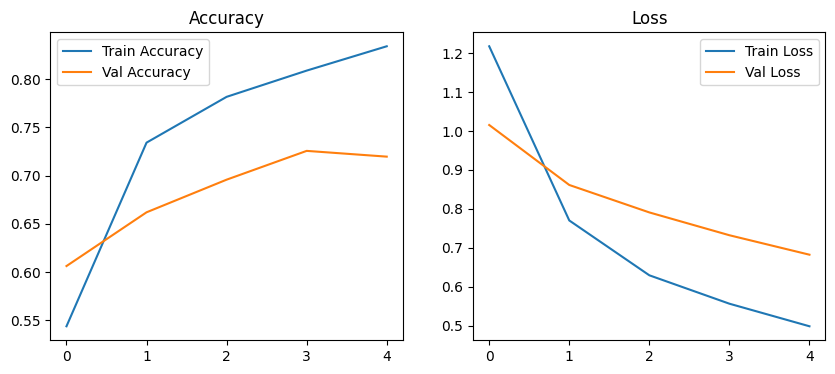

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [20]:
#Check total number of layers
len(base_model.layers)


427

In [21]:
# Unfreeze the top layers of DenseNet121
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Keep the rest frozen
for layer in base_model.layers[:-50]:
    layer.trainable = False


In [22]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # lower LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [23]:
trainable_count = sum([1 for layer in model.layers if layer.trainable])
non_trainable_count = sum([1 for layer in model.layers if not layer.trainable])

print("Trainable layers:", trainable_count)
print("Non-trainable layers:", non_trainable_count)


Trainable layers: 53
Non-trainable layers: 377


In [24]:
FINE_TUNE_EPOCHS = 5

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS
)


Epoch 1/5
127/127 [==============================] - 286s 2s/step - loss: 0.6327 - accuracy: 0.7708 - val_loss: 0.6872 - val_accuracy: 0.7416
Epoch 2/5
127/127 [==============================] - 272s 2s/step - loss: 0.5221 - accuracy: 0.8137 - val_loss: 0.6622 - val_accuracy: 0.7475
Epoch 3/5
127/127 [==============================] - 280s 2s/step - loss: 0.4992 - accuracy: 0.8305 - val_loss: 0.6575 - val_accuracy: 0.7495
Epoch 4/5
127/127 [==============================] - 366s 3s/step - loss: 0.4549 - accuracy: 0.8483 - val_loss: 0.6206 - val_accuracy: 0.7555
Epoch 5/5
127/127 [==============================] - 357s 3s/step - loss: 0.4414 - accuracy: 0.8538 - val_loss: 0.6397 - val_accuracy: 0.7515


In [25]:
model.save("../models/densenet121_finetuned.h5")
print("Fine-tuned DenseNet121 model saved.")


Fine-tuned DenseNet121 model saved.


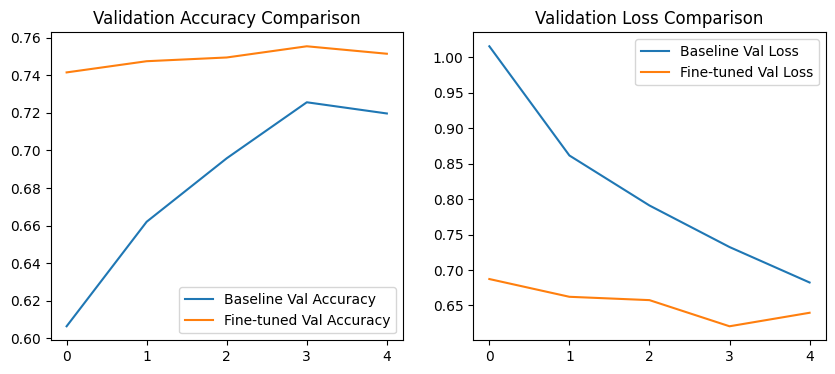

In [26]:

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["val_accuracy"], label="Baseline Val Accuracy")
plt.plot(history_finetune.history["val_accuracy"], label="Fine-tuned Val Accuracy")
plt.legend()
plt.title("Validation Accuracy Comparison")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["val_loss"], label="Baseline Val Loss")
plt.plot(history_finetune.history["val_loss"], label="Fine-tuned Val Loss")
plt.legend()
plt.title("Validation Loss Comparison")

plt.show()
